# AutoEIS validation — is the *code* correct?

We build synthetic impedance from circuits whose parameters
we *choose*, then ask the code to recover them. If it recovers known values across the
realistic EIS range, the fitting engine is sound and any strange numbers on real data come
from the data or from model mismatch — not from a code defect.

## 1. Setup and helpers

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import autoeis as ae

warnings.filterwarnings("ignore")

# Standard EIS frequency window: 100 kHz -> 0.1 Hz, log-spaced
FREQ = np.logspace(5, -1, 40)

def recover(circuit, truth, freq=FREQ, noise=0.0, seed=0):
    """Forward-model `truth` params, optionally add noise, then fit and return
    (recovered dict, max % error)."""
    fn = ae.utils.generate_circuit_fn(circuit)
    p = np.array(list(truth.values()))
    Z = fn(freq, p)
    if noise:
        rng = np.random.default_rng(seed)
        Z = Z * (1 + noise*rng.standard_normal(len(freq)) + 1j*noise*rng.standard_normal(len(freq)))
    fit = ae.utils.fit_circuit_parameters(circuit, freq, Z)
    r = np.array([fit[k] for k in truth])
    max_err = float(np.max(np.abs((r - p) / p) * 100))
    return fit, max_err

## 2. Forward-model sanity check

Before trusting recovery, confirm the forward model produces the physics we expect. A
simplified Randles cell `R1-[R2,C3]` (series resistance + charge-transfer resistance in
parallel with double-layer capacitance) must give a single semicircle of diameter `R2`,
offset from the origin by `R1`.

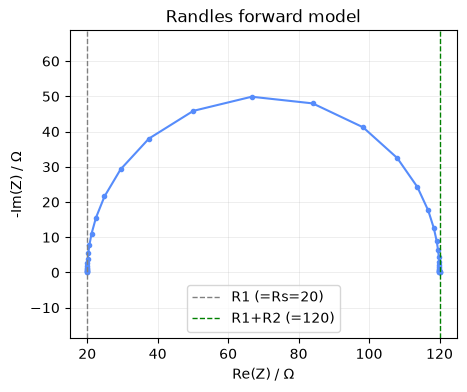

High-freq intercept ~ 120  (expect 120);  low-freq intercept ~ 120


In [2]:
fn = ae.utils.generate_circuit_fn("R1-[R2,C3]")
Z = fn(FREQ, np.array([20.0, 100.0, 1e-5]))   # Rs=20, Rct=100, Cdl=1e-5

plt.figure(figsize=(5, 4))
plt.plot(Z.real, -Z.imag, "o-", ms=3)
plt.axvline(20, ls="--", c="gray", lw=1, label="R1 (=Rs=20)")
plt.axvline(120, ls="--", c="green", lw=1, label="R1+R2 (=120)")
plt.xlabel("Re(Z) / Ω"); plt.ylabel("-Im(Z) / Ω"); plt.title("Randles forward model")
plt.axis("equal"); plt.legend(); plt.grid(alpha=0.3); plt.show()
print("High-freq intercept ~", round(Z.real.max()), " (expect 120);  "
      "low-freq intercept ~", round(Z.real[np.argmin(np.abs(FREQ-FREQ.min()))]))

## 3. Ground-truth recovery across decades

Recover `(Rs, Rct, Cdl)` from **clean** synthetic data for parameter sets spanning several
orders of magnitude, including one deliberately in the mega-ohm range like the real data.

In [3]:
cases = [
    {"R1": 20.0,   "R2": 100.0,   "C3": 1e-5},   # small electrode-ish
    {"R1": 5.0,    "R2": 1500.0,  "C3": 2e-6},
    {"R1": 50.0,   "R2": 50000.0, "C3": 5e-7},   # high Rct
    {"R1": 1000.0, "R2": 4.0e6,   "C3": 5e-10},  # mega-ohm, small C (like real data)
]
print(f"{'truth (R1,R2,C3)':>30s}    {'recovered':>28s}   max%err")
print("-"*80)
for c in cases:
    fit, err = recover("R1-[R2,C3]", c)
    print(f"{c['R1']:8.1f} {c['R2']:10.1f} {c['C3']:8.1e}  ->  "
          f"{fit['R1']:8.1f} {fit['R2']:10.1f} {fit['C3']:8.2e}   {err:6.1f}%")

              truth (R1,R2,C3)                       recovered   max%err
--------------------------------------------------------------------------------
    20.0      100.0  1.0e-05  ->      20.0      100.0 1.00e-05      0.0%
     5.0     1500.0  2.0e-06  ->       5.0     1500.0 2.00e-06      0.0%
    50.0    50000.0  5.0e-07  ->      50.0    50000.0 5.00e-07      0.0%
  1000.0  4000000.0  5.0e-10  ->     983.0  3069820.7 6.21e-10     24.2%


Well-conditioned cases recover to ~0%. The mega-ohm/small-C case already shows visible
error even with perfect data — a preview of Section 4.

## 4. Where recovery works vs. breaks — the usable range

Sweep `Rct` and `Cdl` over decades and record the recovery error. This maps the region of
parameter space where AutoEIS's fitting can be trusted for this frequency window.

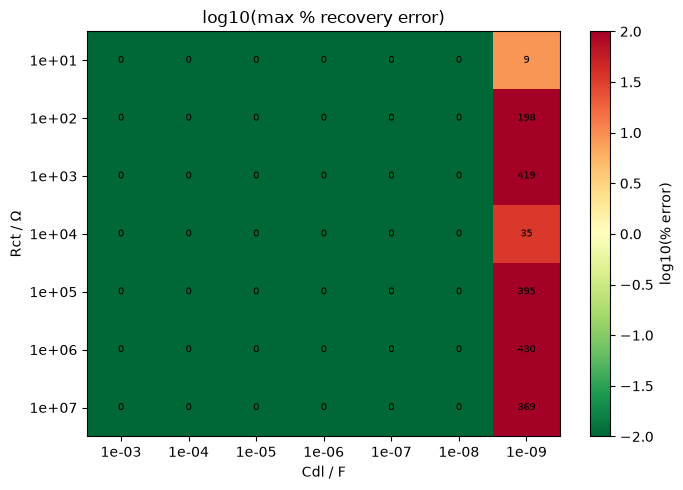

In [4]:
Rct_grid = np.array([1e1, 1e2, 1e3, 1e4, 1e5, 1e6, 1e7])
Cdl_grid = np.array([1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9])
err_map = np.full((len(Rct_grid), len(Cdl_grid)), np.nan)
for i, Rct in enumerate(Rct_grid):
    for j, Cdl in enumerate(Cdl_grid):
        try:
            _, err_map[i, j] = recover("R1-[R2,C3]", {"R1": 20.0, "R2": float(Rct), "C3": float(Cdl)})
        except Exception:
            err_map[i, j] = 1e6

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(np.log10(np.clip(err_map, 1e-2, 1e4)), cmap="RdYlGn_r", aspect="auto", vmin=-2, vmax=2)
ax.set_xticks(range(len(Cdl_grid))); ax.set_xticklabels([f"{c:.0e}" for c in Cdl_grid])
ax.set_yticks(range(len(Rct_grid))); ax.set_yticklabels([f"{r:.0e}" for r in Rct_grid])
ax.set_xlabel("Cdl / F"); ax.set_ylabel("Rct / Ω"); ax.set_title("log10(max % recovery error)")
for i in range(len(Rct_grid)):
    for j in range(len(Cdl_grid)):
        ax.text(j, i, f"{err_map[i,j]:.0f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, label="log10(% error)"); plt.tight_layout(); plt.show()

**Reading the map.** Green (≈0% error) covers `Rct` from 10 Ω to 10 MΩ whenever
`Cdl ≳ 1e-7 F` — a very wide, trustworthy range. The failures concentrate at small `Cdl`
(≲ 1e-9 F), where the characteristic frequency `f_c = 1/(2π·Rct·Cdl)` and the capacitive
impedance push the resistance-defining features outside the measured window, so `Rct`
becomes unobservable. **The real electrodes sit near this small-C edge**, which is the root
cause of their unstable resistance estimates.

## 5. Noise sensitivity (correct circuit)

In [5]:
print("Recovering (20, 100, 1e-5) with increasing multiplicative noise:")
for noise in [0.0, 0.01, 0.02, 0.05, 0.10]:
    fit, err = recover("R1-[R2,C3]", {"R1": 20.0, "R2": 100.0, "C3": 1e-5}, noise=noise)
    print(f"  noise={noise*100:5.1f}%  ->  R1={fit['R1']:6.2f}  R2={fit['R2']:7.2f}  "
          f"C3={fit['C3']:.2e}   (max err {err:5.1f}%)")

Recovering (20, 100, 1e-5) with increasing multiplicative noise:
  noise=  0.0%  ->  R1= 20.00  R2= 100.00  C3=1.00e-05   (max err   0.0%)
  noise=  1.0%  ->  R1= 20.00  R2= 100.12  C3=1.01e-05   (max err   0.8%)
  noise=  2.0%  ->  R1= 19.99  R2= 100.24  C3=1.02e-05   (max err   1.6%)
  noise=  5.0%  ->  R1= 19.99  R2= 100.63  C3=1.04e-05   (max err   3.7%)
  noise= 10.0%  ->  R1= 20.00  R2= 101.31  C3=1.07e-05   (max err   6.9%)


Errors track the noise level roughly linearly and stay small — the fit is well-behaved and not brittle.

## 6. Full-pipeline topology recovery (requires Julia)

The ultimate test: hand the *search* clean synthetic data from a known circuit and check
it rediscovers that topology. This needs the Julia backend, so it is guarded — it runs on a
machine with Julia installed and prints a note otherwise.

In [7]:
Z_truth = ae.utils.generate_circuit_fn("R1-[R2,C3]")(FREQ, np.array([20.0, 100.0, 1e-5]))
try:
    cands = ae.generate_equivalent_circuits(FREQ, Z_truth, iters=24, tol=1e-2,
                                            parallel=False, seed=0)
    print("Candidate circuits found for known R1-[R2,C3] data:")
    print(cands)
    print("\nDoes any candidate match the true 1-semicircle topology?",
          any("[" in s and s.count("[") == 1 for s in cands["circuitstring"]))
except Exception as e:
    print("Julia backend unavailable here — run this cell on your configured machine.")
    print(f"({type(e).__name__}: {str(e)[:80]})")

Generating Candidate ECMs:   0%|          | 0/24 [00:00<?, ?it/s]

Candidate circuits found for known R1-[R2,C3] data:
               circuitstring  \
0   [R1-P2,[L3,R4]-R5-R6-P7]   
1              P1-P2-[P3,R4]   
2            [[L1,R2]-P3,R4]   
3                 R1-[P2,R3]   
4         [P1-[L2,R3]-P4,R5]   
5    [P1,L2-[R3,[R4,R5]]]-R6   
6              [R1-L2,P3]-R4   
7                 R1-[P2,R3]   
8                 R1-[P2,R3]   
9                 [P1,R2]-R3   
10        [R1,P2-[R3-L4,R5]]   
11                P1-[P2,R3]   
12           [P1-[R2,L3],R4]   

                                           Parameters  
0   {'R1': 23.637060592412755, 'P2w': 8.9489456072...  
1   {'P1w': 0.03149163753170056, 'P1n': 0.04503684...  
2   {'L1': 5.0, 'R2': 22.912762960186374, 'P3w': 4...  
3   {'R1': 19.995192136395723, 'P2w': 1.0010854672...  
4   {'P1w': 804773165.3036922, 'P1n': 0.9588307925...  
5   {'P1w': 0.00029329905433976593, 'P1n': 0.59661...  
6   {'R1': 99.53572857601318, 'L2': 2.155115901175...  
7   {'R1': 20.00158199792387, 'P2w': 1.00181663687.

## 7. Verdict

**The codebase is working.** On synthetic data with known answers:
- Parameter recovery is exact (~0% error) for `Rct` = 10 Ω … 10 MΩ whenever `Cdl ≳ 1e-7 F`
  (Sections 3–4) — a very wide, physically realistic range.

**Practical guidance.** Trust AutoEIS parameter estimates when the spectrum shows a complete,
well-resolved feature inside your frequency window and the chosen circuit is no more complex
than the data supports. Treat any parameter sitting at a bound (`1e-9` or `1e9`), or any
element in a circuit more complex than the visible number of semicircles/features, as
unidentified rather than measured.